<div style="
    display: inline-block;
    background: linear-gradient(135deg, #CC670E, #DE802F);
    color: white;
    font-size: 1.8rem;
    font-weight: bold;
    padding: 15px 30px;
    border-radius: 12px;
    text-align: center;
    border: 5px solid #854419;
    box-shadow: 4px 4px 10px rgba(0, 0, 0, 0.2);
    letter-spacing: 1px;
"> 
    🧑‍🎓 Educational Backgrounds of Successful People 🧑‍🎓
</div>

Success is often portrayed as the result of talent, hard work, and opportunity. However, one of the most influential factors shaping an individual’s trajectory is education. Educational background not only provides technical knowledge and credentials, but also shapes networks, confidence, critical thinking skills, and access to opportunities.

This notebook explores the relationship between educational backgrounds and indicators of success across different fields. Through data analysis techniques, we aim to identify patterns, correlations, and trends that reveal how variables such as level of education, field of study, institution type, and socioeconomic factors may influence professional and financial outcomes.

### <div style="display: inline-block; border-radius: 50px; background: linear-gradient(130deg, #37454F);color: white; padding: 10px 25px;font-weight: 600;box-shadow: 0 4px 12px rgb(255, 255, 255);color: white;"><b>1 |</b> Data Loading and Cleaning</div>

In [2]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

In [3]:
""" file = '/kaggle/input/educational-backgrounds-of-successful-people/successful_educations.csv' """
file = 'successful_educations.csv'
df = pd.read_csv(file)

In [7]:
print("Shape of the DataFrame:", df.shape)

Shape of the DataFrame: (525, 10)


In [4]:
df.head()

,Name,Profession,Degree,Field,Institution,Graduation Year,Country,University Global Ranking,GPA (or Equivalent),Scholarship/Award
0,Elon Musk,Entrepreneur,Bachelor of Science,Physics & Economics,University of Pennsylvania,1997,USA,13,3.7,Dean’s List
1,Bill Gates,Entrepreneur,Dropped Out,computer science,Harvard University,1975,USA,5,NaN,Dean’s List
2,Sundar Pichai,Tech Executive,Master of Science,Material Sciences and Engineering,Stanford University,1995,USA,3,3.8,Fellowship in Engineering
3,Sheryl Sandberg,Tech Executive,Master of Business Administration,Business Administration,Harvard Business School,1995,USA,2,3.9,Hoover Fellowship
4,Jeff Bezos,Entrepreneur,Bachelor of Science,Computer Science and Electrical Engineering,Princeton University,1986,USA,16,3.6,Marquis Scholar


In [9]:
df.describe()

,Name,Profession,Degree,Field,Institution,Graduation Year,Country,University Global Ranking,GPA (or Equivalent),Scholarship/Award
count,525,525,518,490,512,498,524,302,117,488
unique,523,100,85,160,276,124,40,67,12,351
top,Jack Dorsey,Entrepreneur,Doctor of Philosophy,Physics,Harvard University,1993,USA,4,3.8,Emmy Winner
freq,2,44,112,47,34,16,334,33,24,13


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525 entries, 0 to 524
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Name                       525 non-null    object
 1   Profession                 525 non-null    object
 2   Degree                     518 non-null    object
 3   Field                      490 non-null    object
 4   Institution                512 non-null    object
 5   Graduation Year            498 non-null    object
 6   Country                    524 non-null    object
 7   University Global Ranking  302 non-null    object
 8   GPA (or Equivalent)        117 non-null    object
 9   Scholarship/Award          488 non-null    object
dtypes: object(10)
memory usage: 41.1+ KB


In [18]:
df['Graduation Year'] = pd.to_numeric(df['Graduation Year'], errors='coerce')
df['Graduation Year'] = df['Graduation Year'].fillna(0).astype(int)

df['GPA_numeric'] = pd.to_numeric(df['GPA (or Equivalent)'], errors='coerce')
mean_gpa = df['GPA_numeric'].mean()
df['GPA_numeric'] = df['GPA_numeric'].fillna(mean_gpa)

df['Scholarship/Award'] = df['Scholarship/Award'].fillna('None')

df['Institution'] = df['Institution'].fillna('Unknown')


In [15]:
# Normalize field of study
def normalize_field(field):
    if pd.isna(field):
        return 'Unknown'
    
    field = str(field).lower()
    
    if 'comput' in field or 'software' in field or 'information' in field:
        return 'Computer Science/IT'
    elif 'business' in field or 'management' in field or 'administration' in field:
        return 'Business/Management'
    elif 'engineer' in field:
        return 'Engineering'
    elif 'econom' in field or 'finance' in field:
        return 'Economics/Finance'
    elif 'law' in field:
        return 'Law'
    elif 'math' in field:
        return 'Mathematics'
    elif 'physic' in field:
        return 'Physics'
    elif 'biolog' in field or 'medic' in field or 'pharmac' in field or 'animal' in field:
        return 'Biology/Medicine'
    elif 'english' in field or 'literature' in field or 'creative' in field:
        return 'Literature/Writing'
    elif 'psycholog' in field or 'sociolog' in field or 'anthropolog' in field:
        return 'Social Sciences'
    elif 'art' in field or 'music' in field or 'theater' in field or 'drama' in field or 'film' in field:
        return 'Arts/Performance'
    else:
        return 'Other'

df['Field'] = df['Field'].apply(normalize_field)

In [16]:
# Normalize profession 
def normalize_profession(profession):
    if pd.isna(profession):
        return 'Unknown'
    
    profession = str(profession).lower()
    
    if 'entrepreneur' in profession or 'business' in profession or 'ceo' in profession or 'founder' in profession:
        return 'Entrepreneur/Business'
    elif 'tech' in profession or 'software' in profession or 'computer' in profession:
        return 'Tech Executive'
    elif 'finance' in profession or 'investor' in profession:
        return 'Finance/Investment'
    elif 'actor' in profession or 'comedian' in profession or 'musician' in profession or 'artist' in profession:
        return 'Entertainment'
    elif 'scientist' in profession or 'physicist' in profession or 'researcher' in profession:
        return 'Scientist/Researcher'
    elif 'author' in profession or 'writer' in profession or 'journalist' in profession:
        return 'Author/Writer'
    elif 'politician' in profession or 'activist' in profession:
        return 'Politician/Activist'
    elif 'lawyer' in profession:
        return 'Lawyer'
    elif 'athlete' in profession:
        return 'Athlete'
    elif 'fashion' in profession:
        return 'Fashion'
    else:
        return 'Other'

df['Profession'] = df['Profession'].apply(normalize_profession)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525 entries, 0 to 524
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Name                       525 non-null    object 
 1   Profession                 525 non-null    object 
 2   Degree                     525 non-null    object 
 3   Field                      525 non-null    object 
 4   Institution                525 non-null    object 
 5   Graduation Year            525 non-null    int32  
 6   Country                    524 non-null    object 
 7   University Global Ranking  302 non-null    object 
 8   GPA (or Equivalent)        117 non-null    object 
 9   Scholarship/Award          525 non-null    object 
 10  GPA_numeric                525 non-null    float64
dtypes: float64(1), int32(1), object(9)
memory usage: 43.2+ KB


In [20]:
df.head()

,Name,Profession,Degree,Field,Institution,Graduation Year,Country,University Global Ranking,GPA (or Equivalent),Scholarship/Award,GPA_numeric
0,Elon Musk,Entrepreneur/Business,Bachelor of Science,Economics/Finance,University of Pennsylvania,1997,USA,13,3.7,Dean’s List,3.700000
1,Bill Gates,Entrepreneur/Business,Dropped Out,Computer Science/IT,Harvard University,1975,USA,5,NaN,Dean’s List,3.744554
2,Sundar Pichai,Tech Executive,Master of Science,Engineering,Stanford University,1995,USA,3,3.8,Fellowship in Engineering,3.800000
3,Sheryl Sandberg,Tech Executive,Master of Business Administration,Business/Management,Harvard Business School,1995,USA,2,3.9,Hoover Fellowship,3.900000
4,Jeff Bezos,Entrepreneur/Business,Bachelor of Science,Computer Science/IT,Princeton University,1986,USA,16,3.6,Marquis Scholar,3.600000


### <div style="display: inline-block; border-radius: 50px; background: linear-gradient(130deg, #37454F);color: white; padding: 10px 25px;font-weight: 600;box-shadow: 0 4px 12px rgb(255, 255, 255);"><b>2 |</b> Data Analysis and Visualization</div>

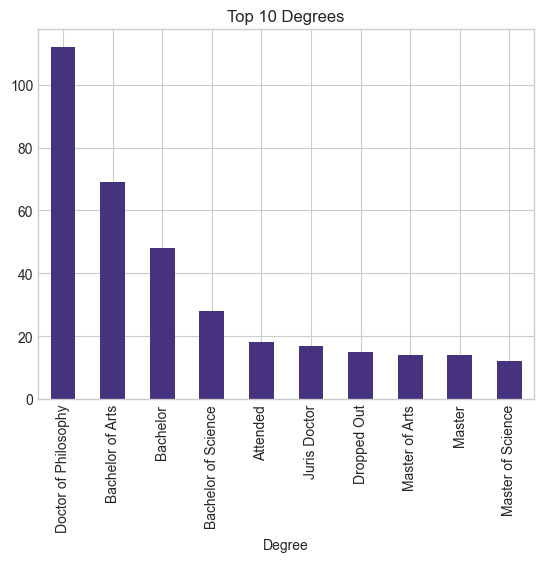

In [29]:
df['Degree'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Degrees")
plt.xticks()
plt.show()

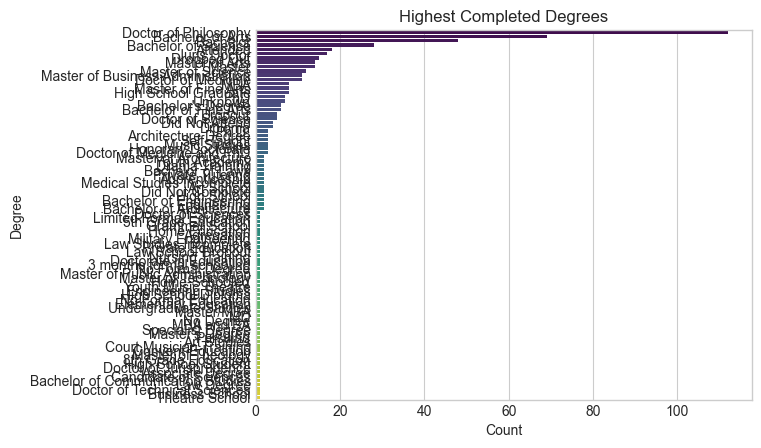

In [64]:
sns.countplot(y=df['Degree'], order=df['Degree'].value_counts().index, palette="viridis")
plt.title("Highest Completed Degrees")
plt.xlabel("Count")
plt.ylabel("Degree")
plt.show()

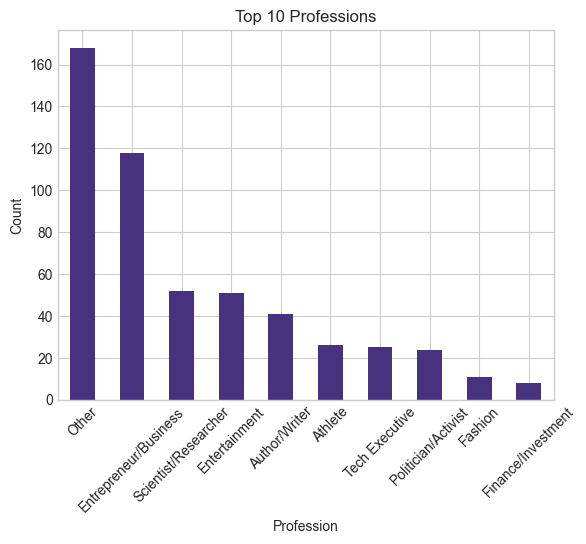

In [ ]:
top_professions = df['Profession'].value_counts().head(10)

plt.figure()
top_professions.plot(kind='bar')
plt.title("Top 10 Professions")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

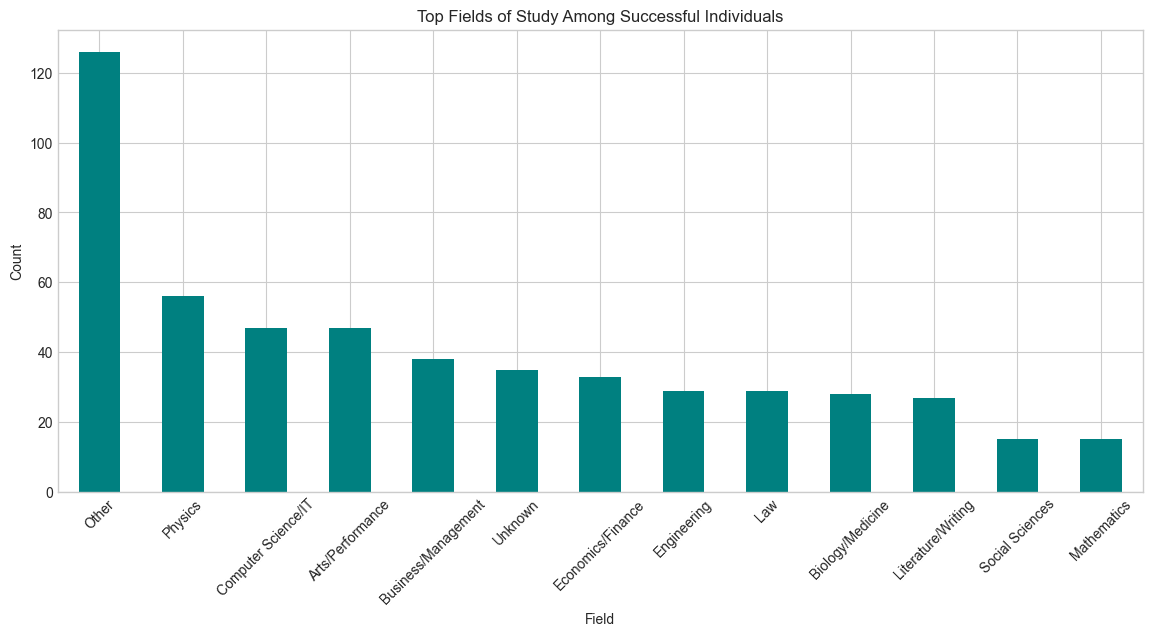

In [37]:
field_counts = df['Field'].value_counts()
plt.figure(figsize=(14, 6))
field_counts[:15].plot(kind='bar', color='teal')
plt.title("Top Fields of Study Among Successful Individuals")
plt.xlabel("Field")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

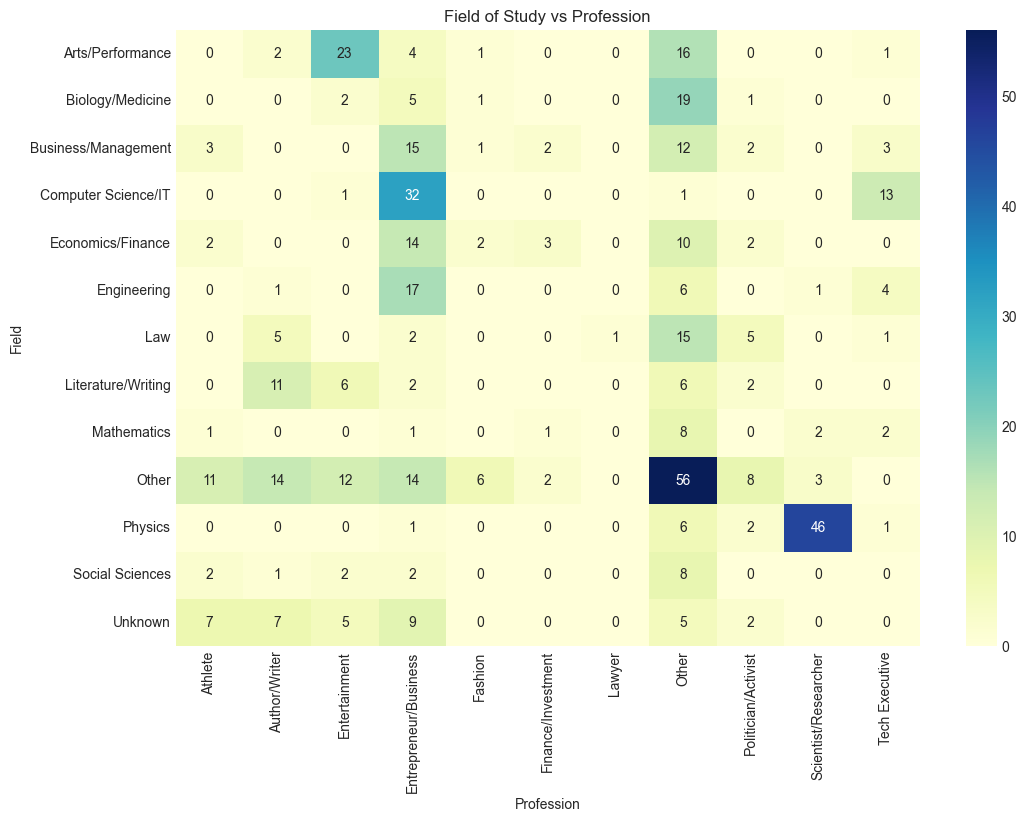

In [27]:
crosstab_fp = pd.crosstab(df['Field'], df['Profession'])
crosstab_fp
plt.figure(figsize=(12,8))
sns.heatmap(crosstab_fp, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Field of Study vs Profession")
plt.show()

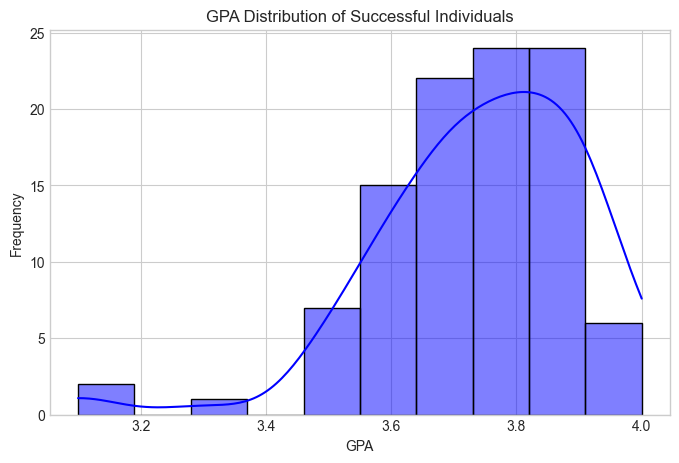

In [43]:
df['GPA (or Equivalent)'] = pd.to_numeric(df['GPA (or Equivalent)'], errors='coerce')
plt.figure(figsize=(8, 5))
sns.histplot(df['GPA (or Equivalent)'].dropna(), bins=10, kde=True, color="blue")
plt.title("GPA Distribution of Successful Individuals")
plt.xlabel("GPA")
plt.ylabel("Frequency")
plt.show()

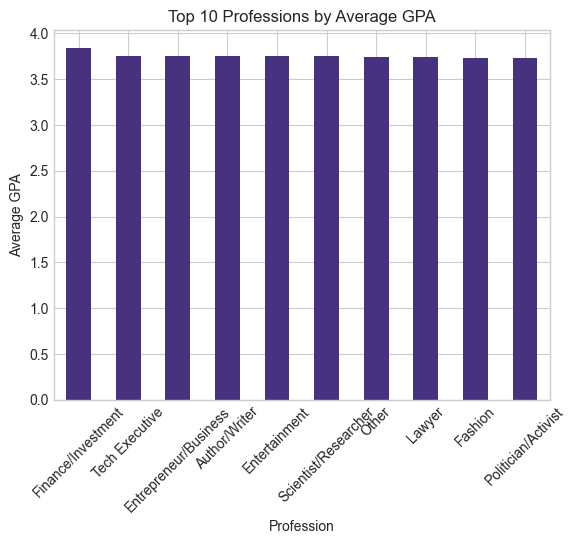

In [41]:
gpa_by_profession = df.groupby('Profession')['GPA_numeric'].mean().sort_values(ascending=False)

plt.figure()
gpa_by_profession.head(10).plot(kind='bar')
plt.title("Top 10 Professions by Average GPA")
plt.ylabel("Average GPA")
plt.xticks(rotation=45)
plt.show()

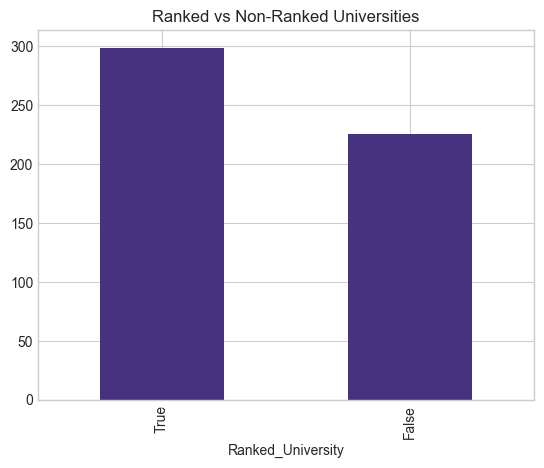

In [45]:
df['University Global Ranking'] = pd.to_numeric(df['University Global Ranking'], errors='coerce')

df['Ranked_University'] = df['University Global Ranking'].notnull()

df['Ranked_University'].value_counts()

plt.figure()
df['Ranked_University'].value_counts().plot(kind='bar')
plt.title("Ranked vs Non-Ranked Universities")
plt.show()

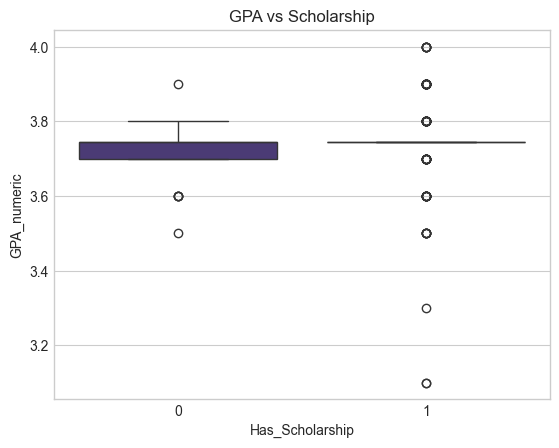

In [46]:
df['Has_Scholarship'] = df['Scholarship/Award'].apply(lambda x: 0 if x == 'None' else 1)

sns.boxplot(x='Has_Scholarship', y='GPA_numeric', data=df)
plt.title("GPA vs Scholarship")
plt.show()

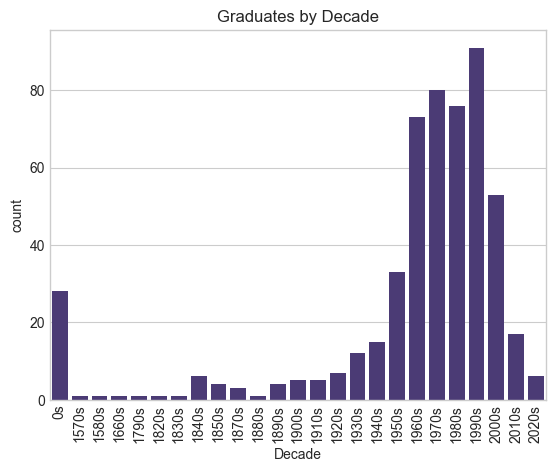

In [50]:
df['Decade'] = (df['Graduation Year'] // 10) * 10
df['Decade'] = df['Decade'].astype(str) + "s"
df['Decade'].value_counts().sort_index()

plt.figure()
sns.countplot(x='Decade', data=df, order=sorted(df['Decade'].unique()))
plt.xticks(rotation=90)
plt.title("Graduates by Decade")
plt.show()

In [51]:
field_decade = df.groupby(['Decade', 'Field']).size().unstack(fill_value=0)

field_decade.head()

Field,Arts/Performance,Biology/Medicine,Business/Management,Computer Science/IT,Economics/Finance,Engineering,Law,Literature/Writing,Mathematics,Other,Physics,Social Sciences,Unknown
Decade,,,,,,,,,,,,,
0s,5,2,0,2,1,0,0,1,1,3,0,0,13
1570s,0,0,0,0,0,0,0,0,0,1,0,0,0
1580s,0,1,0,0,0,0,0,0,0,0,0,0,0
1660s,0,0,0,0,0,0,0,0,1,0,0,0,0
1790s,1,0,0,0,0,0,0,0,0,0,0,0,0


<Figure size 640x480 with 0 Axes>

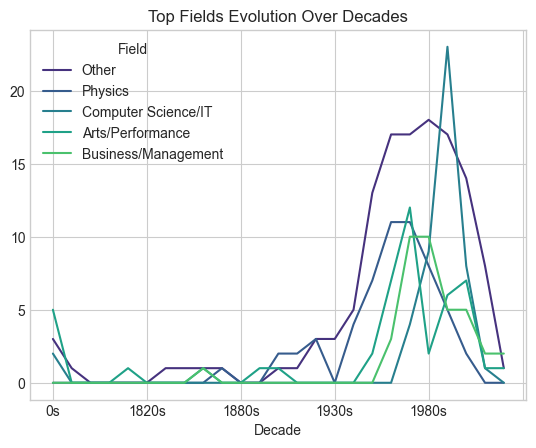

In [52]:
top_fields = df['Field'].value_counts().head(5).index

plt.figure()
field_decade[top_fields].plot()
plt.title("Top Fields Evolution Over Decades")
plt.show()

In [54]:
df['University Global Ranking'] = pd.to_numeric(df['University Global Ranking'], errors='coerce')

def ranking_tier(rank):
    if pd.isna(rank):
        return "Not Ranked"
    elif rank <= 50:
        return "Top 50"
    elif rank <= 200:
        return "Top 200"
    else:
        return "200+"

df['Ranking_Tier'] = df['University Global Ranking'].apply(ranking_tier)

df['Ranking_Tier'].value_counts()

Ranking_Tier
Top 50        257
Not Ranked    226
Top 200        32
200+           10
Name: count, dtype: int64

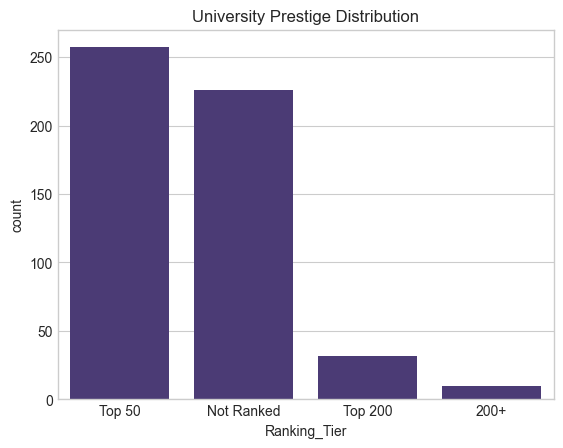

In [56]:
pd.crosstab(df['Profession'], df['Ranking_Tier']).head()

pd.crosstab(df['Profession'], df['Ranking_Tier']).head()
plt.figure()
sns.countplot(x='Ranking_Tier', data=df)
plt.title("University Prestige Distribution")
plt.show()

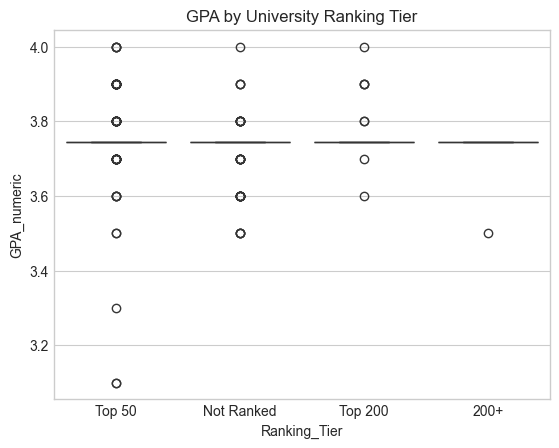

In [57]:
sns.boxplot(x='Ranking_Tier', y='GPA_numeric', data=df)
plt.title("GPA by University Ranking Tier")
plt.show()

In [58]:
field_diversity = df.groupby('Profession')['Field'].nunique().sort_values(ascending=False)

field_diversity.head(10)

Profession
Entrepreneur/Business    13
Other                    13
Politician/Activist       8
Author/Writer             7
Entertainment             7
Tech Executive            7
Athlete                   6
Fashion                   5
Finance/Investment        4
Scientist/Researcher      4
Name: Field, dtype: int64

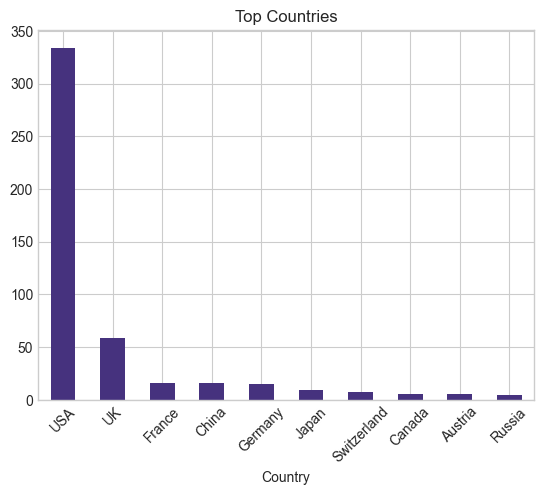

In [59]:
top_countries = df['Country'].value_counts().head(10)

plt.figure()
top_countries.plot(kind='bar')
plt.title("Top Countries")
plt.xticks(rotation=45)
plt.show()

In [60]:
country_ranking = df.groupby('Country')['University Global Ranking'].mean().sort_values()

country_ranking.head(10)

Country
UK                14.425000
USA               27.469027
Canada            29.750000
Switzerland       33.000000
France            48.750000
United Kingdom    49.000000
Netherlands       53.000000
Japan             69.250000
Germany           80.000000
Denmark           84.000000
Name: University Global Ranking, dtype: float64

In [61]:
def gpa_category(gpa):
    if gpa >= 3.7:
        return "High"
    elif gpa >= 3.0:
        return "Medium"
    else:
        return "Low"

df['GPA_Category'] = df['GPA_numeric'].apply(gpa_category)

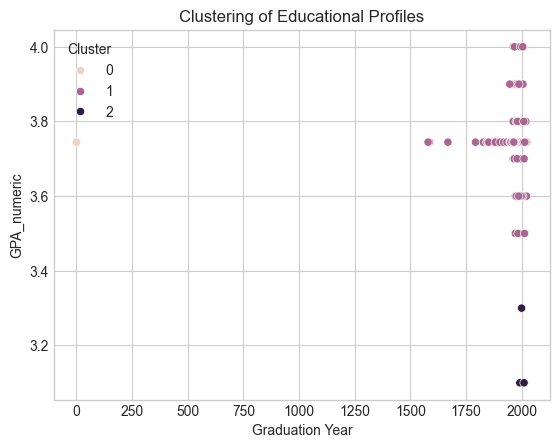

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = df[['Graduation Year', 'GPA_numeric']].dropna()

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled)

features['Cluster'] = clusters

sns.scatterplot(x=features['Graduation Year'], 
                y=features['GPA_numeric'], 
                hue=features['Cluster'])
plt.title("Clustering of Educational Profiles")
plt.show()